<a href="https://colab.research.google.com/github/lazic7/MSAP/blob/master/LV7_priprema.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import scipy.stats as stats
from scipy.stats import levene
from statsmodels.stats.anova import anova_lm
from statsmodels.multivariate.manova import MANOVA

In [3]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
df.shape

(1000, 8)

In [8]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
numericke = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
kategorijske = df.select_dtypes(include=["object"]).columns.tolist()

numericke, kategorijske

(['math score', 'reading score', 'writing score'],
 ['gender',
  'race/ethnicity',
  'parental level of education',
  'lunch',
  'test preparation course'])

**Provjera razina faktora koje koristimo**

In [11]:
df["gender"].value_counts()

,count
gender,
female,518
male,482


In [12]:
df["test preparation course"].value_counts()

,count
test preparation course,
none,642
completed,358


***Deskriptivna analiza***

In [14]:
group_means = df.groupby(
    ['gender', 'test preparation course']
)['math score'].mean()

group_means

gender  test preparation course
female  completed                  67.195652
        none                       61.670659
male    completed                  72.339080
        none                       66.688312
Name: math score, dtype: float64

**Vizualizacija**

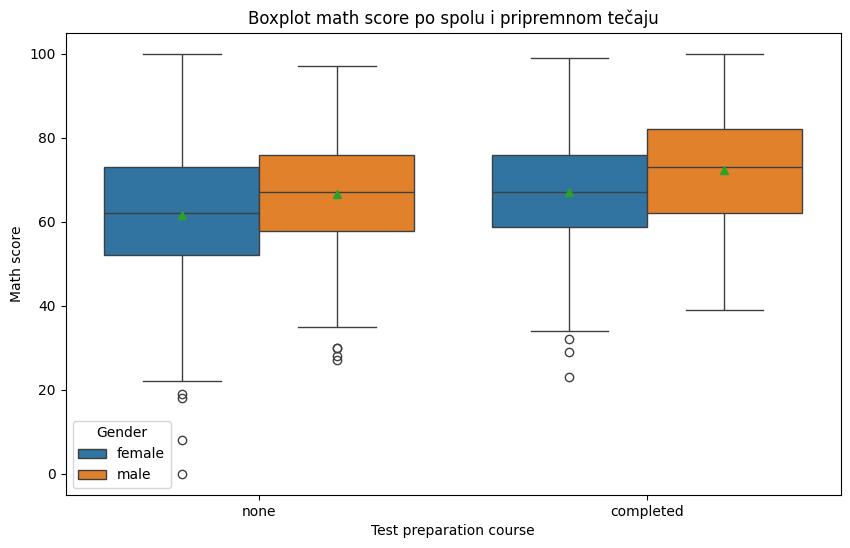

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='test preparation course',
    y='math score',
    hue='gender',
    data=df,
    showmeans=True
)

plt.title('Boxplot math score po spolu i pripremnom tečaju')
plt.xlabel('Test preparation course')
plt.ylabel('Math score')
plt.legend(title='Gender')
plt.show()

Deskriptivna analiza pokazuje da učenici koji su pohađali pripremni tečaj u prosjeku ostvaruju više rezultate iz matematike u odnosu na učenike koji nisu pohađali tečaj, neovisno o spolu. Također se uočavaju razlike u srednjim vrijednostima između učenika i učenica, što upućuje na mogući glavni efekt oba faktora.

In [17]:
means = df.groupby(
    ['test preparation course', 'gender']
)['math score'].mean().unstack()

means

gender,female,male
test preparation course,,
completed,67.195652,72.339080
none,61.670659,66.688312


<Figure size 800x600 with 0 Axes>

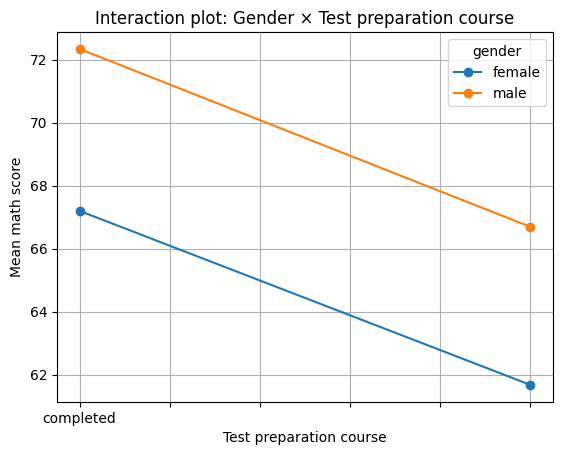

In [18]:
plt.figure(figsize=(8, 6))
means.plot(marker='o')

plt.xlabel('Test preparation course')
plt.ylabel('Mean math score')
plt.title('Interaction plot: Gender × Test preparation course')
plt.grid(True)
plt.show()

Graf interakcije pokazuje da su linije koje predstavljaju spol učenika
približno paralelne, što upućuje da nema izraženog interakcijskog
efekta između spola i pohađanja pripremnog tečaja.

**Provjera pretpostavki Two-Way ANOVA-e**

**Postavljanje modela**

In [22]:
model = smf.ols(
    "Q('math score') ~ C(gender) * C(Q('test preparation course'))",
    data=df
).fit()

**Analiza normalnosti reziduala**

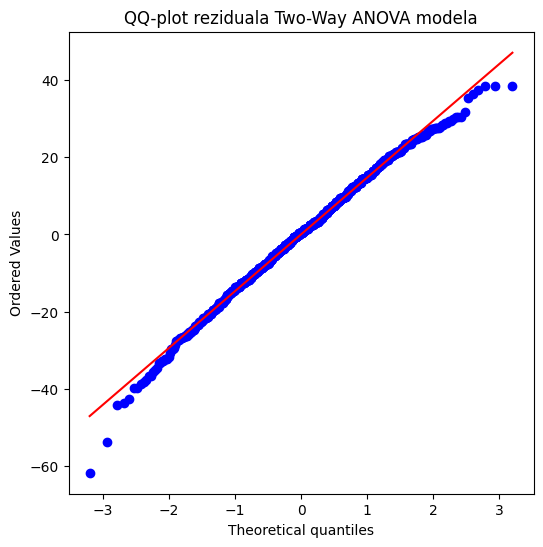

In [24]:
residuals = model.resid

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot reziduala Two-Way ANOVA modela")
plt.show()


QQ-plot reziduala pokazuje da reziduali u velikoj mjeri prate teorijsku
normalnu razdiobu, uz manja odstupanja na krajevima distribucije.
Pretpostavka normalnosti reziduala smatra se zadovoljenom.

**Homogenost varijanci — Levene test**

In [27]:
groups = [
    group["math score"].values
    for _, group in df.groupby(["gender", "test preparation course"])
]

In [29]:
stat, p = levene(*groups, center="median")
print(f"Statistika: {stat:.4f}")
print(f"P-vrijednost: {p:.4f}")

Statistika: 1.1342
P-vrijednost: 0.3342


Leveneov test nije pokazao statistički značajnu razliku
varijanci između skupina (p = 0.3342), čime je pretpostavka homogenosti
varijanci zadovoljena

**Two-Way ANOVA - tablica i testiranje hipoteza**

In [31]:
anova_results = anova_lm(model, typ=2)
anova_results

,sum_sq,df,F,PR(>F)
C(gender),6399.209637,1.0,29.502577,7.018859e-08
C(Q('test preparation course')),7170.996015,1.0,33.060780,1.187245e-08
C(gender):C(Q('test preparation course')),0.907979,1.0,0.004186,9.484258e-01
Residual,216035.801152,996.0,NaN,NaN


U tablici imaš redove:

C(gender) → glavni efekt spola

C(Q('test preparation course')) → glavni efekt pripremnog tečaja

C(gender):C(Q('test preparation course')) → interakcijski efekt

Residual → pogreška

Za svaki red gledaš:

F-vrijednost

p-vrijednost (PR(>F))

1️⃣ Glavni efekt spola

H0: μ_male = μ_female

Ako je p < 0.05 → spol ima statistički značajan utjecaj na math score

Primjer rečenice:

Rezultati Two-Way ANOVA-e pokazuju da spol učenika ima statistički
značajan značajan utjecaj na rezultate iz matematike
(p = 0.0000).

2️⃣ Glavni efekt pripremnog tečaja

H0: μ_completed = μ_none

Ako je p < 0.05 → pripremni tečaj ima statistički značajan utjecaj

Primjer rečenice:

Utvrđen je statistički značajan glavni efekt pohađanja pripremnog tečaja
na rezultat iz matematike (p = 0.0000), pri čemu učenici koji su pohađali
tečaj ostvaruju više prosječne rezultate.

3️⃣ Interakcijski efekt (NAJVAŽNIJI DIO)

H0: nema interakcije

Ako je p < 0.05 → postoji interakcija

Ako je p ≥ 0.05 → nema interakcije

Ako interakcija NIJE značajna (najčešći slučaj):

Interakcijski efekt između spola i pohađanja pripremnog tečaja nije
statistički značajan (p = 0.09484), što upućuje na to da učinak pripremnog
tečaja ne ovisi o spolu učenika.

**Interakcija nije znacajna, interpretiraju se glavni efekti pojedinih faktora.**

**MANOVA - postoji li razlika između grupa u multivarijatnom smislu**

In [32]:
dvs = ["math score", "reading score", "writing score"]

df[dvs].corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


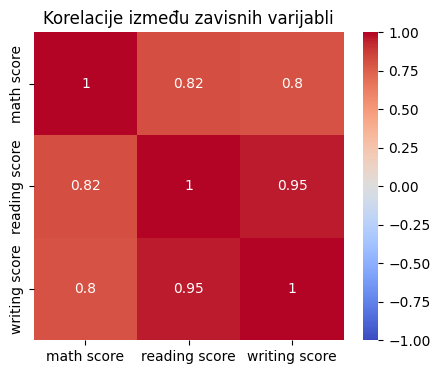

In [33]:
plt.figure(figsize=(5, 4))
sns.heatmap(df[dvs].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelacije između zavisnih varijabli")
plt.show()

Rezultati ispita iz matematike, čitanja i pisanja međusobno su korelirani,
što opravdava primjenu MANOVA-e.

In [34]:
df.groupby(["gender", "test preparation course"]).size()

gender  test preparation course
female  completed                  184
        none                       334
male    completed                  174
        none                       308
dtype: int64

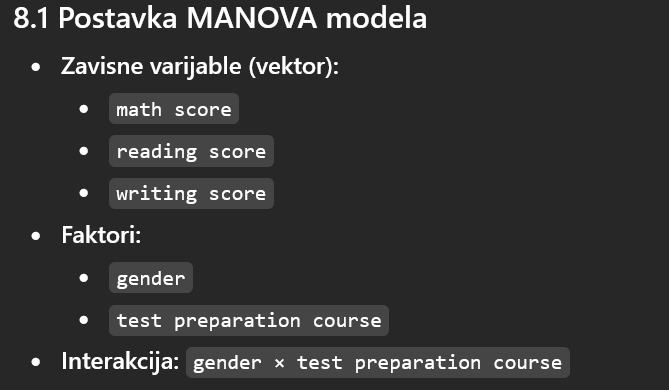

In [36]:
manova = MANOVA.from_formula(
    "Q('math score') + Q('reading score') + Q('writing score') "
    "~ C(gender) * C(Q('test preparation course'))",
    data=df
)

print(manova.mv_test())

                           Multivariate linear model
                                                                                
-----------------------------------------------------------------------------------
            Intercept           Value     Num DF     Den DF      F Value     Pr > F
-----------------------------------------------------------------------------------
               Wilks' lambda    0.1282    3.0000    994.0000    2253.3361    0.0000
              Pillai's trace    0.8718    3.0000    994.0000    2253.3361    0.0000
      Hotelling-Lawley trace    6.8008    3.0000    994.0000    2253.3361    0.0000
         Roy's greatest root    6.8008    3.0000    994.0000    2253.3361    0.0000
--------------------------------------------------------------------------------
                                                                                
-----------------------------------------------------------------------------------
             C(gender)          

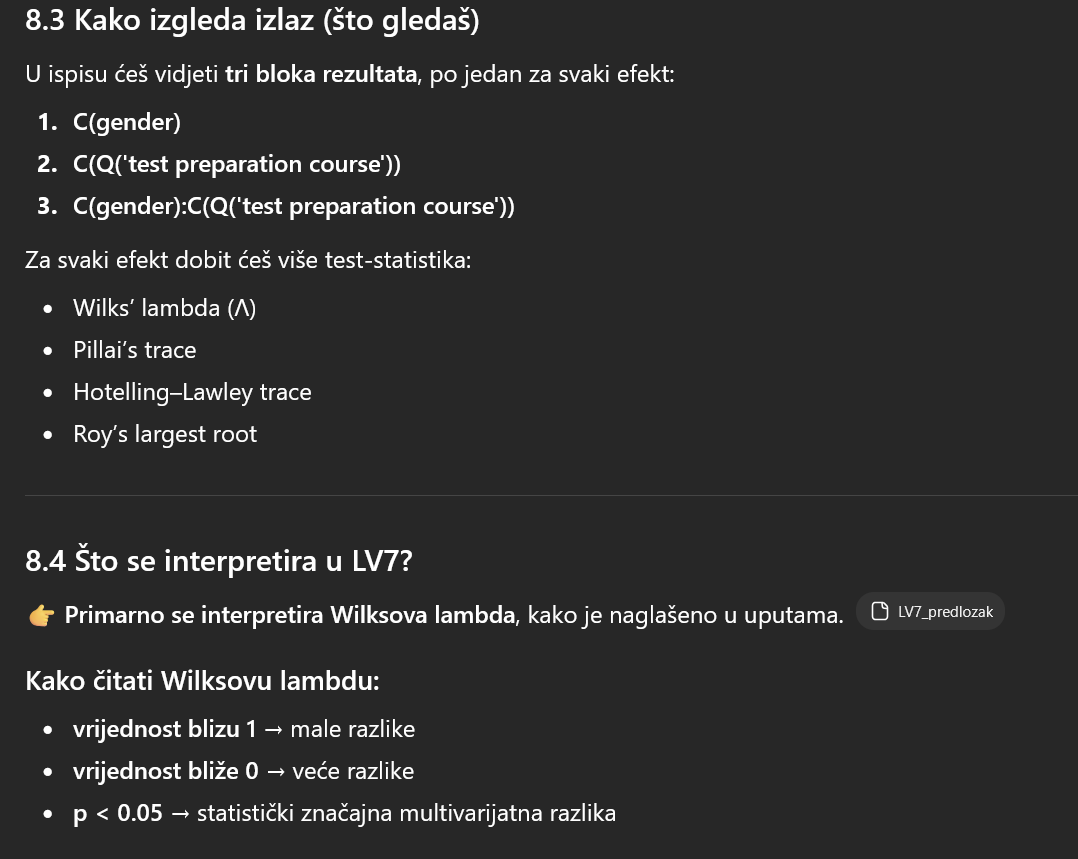

MANOVA analiza pokazuje da postoji statistički značajna razlika u
multivarijatnom profilu rezultata iz matematike, čitanja i pisanja između
učenika različitog spola (Wilks’ Λ = 0.6531, p = 0.0000)

Utvrđen je statistički značajan multivarijatni učinak pohađanja pripremnog
tečaja na ukupni akademski uspjeh učenika, promatran kroz rezultate iz
matematike, čitanja i pisanja (Wilks’ Λ = 0.8845, p = 0.0000).

Interakcijski efekt između spola i pohađanja pripremnog tečaja nije
statistički značajan u multivarijatnom smislu (Wilks’ Λ = 0.9997, p = 0.9535).

**Radi se Univarijatna ANOVA**

In [37]:
for dv in ['math score', 'reading score', 'writing score']:
    model_uv = smf.ols(
        f"Q('{dv}') ~ C(gender) * C(Q('test preparation course'))",
        data=df
    ).fit()

    print(f"\nUnivarijatna ANOVA za: {dv}")
    print(anova_lm(model_uv, typ=2))


Univarijatna ANOVA za: math score
                                                  sum_sq     df          F  \
C(gender)                                    6399.209637    1.0  29.502577   
C(Q('test preparation course'))              7170.996015    1.0  33.060780   
C(gender):C(Q('test preparation course'))       0.907979    1.0   0.004186   
Residual                                   216035.801152  996.0        NaN   

                                                 PR(>F)  
C(gender)                                  7.018859e-08  
C(Q('test preparation course'))            1.187245e-08  
C(gender):C(Q('test preparation course'))  9.484258e-01  
Residual                                            NaN  

Univarijatna ANOVA za: reading score
                                                  sum_sq     df          F  \
C(gender)                                   12863.415867    1.0  68.279387   
C(Q('test preparation course'))             12601.298604    1.0  66.888061   
C(gender):C(

Univarijatne ANOVA-e provedene nakon značajne MANOVA-e pokazuju da
spol učenika ima statistički značajan utjecaj na sve tri zavisne varijable:
rezultat iz matematike, čitanja i pisanja (p < 0.05). Također je utvrđen
statistički značajan glavni efekt pohađanja pripremnog tečaja za sve tri
zavisne varijable, dok interakcijski efekt između spola i pripremnog
tečaja nije statistički značajan ni za jednu zavisnu varijablu.

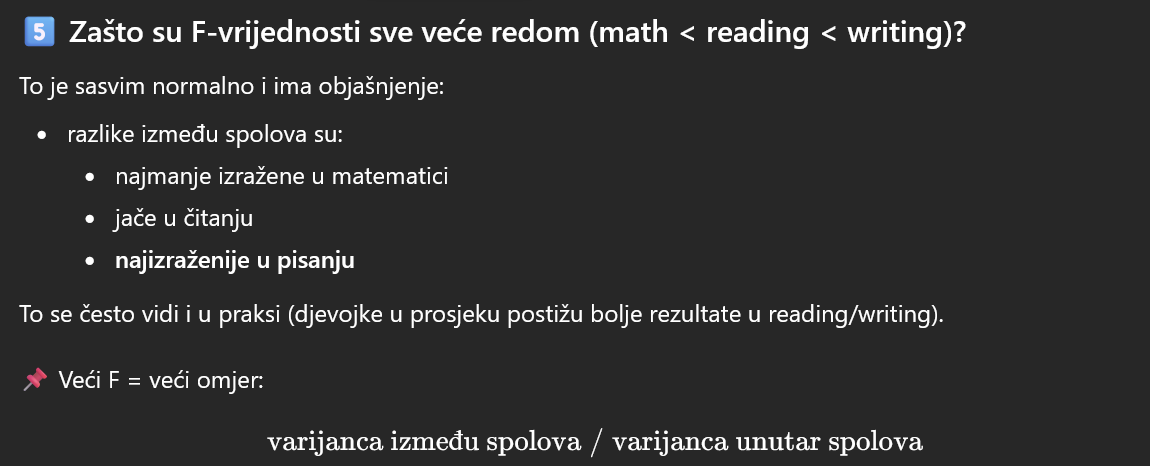